# **Beta diversity - Acus**

# **1. Packages and libraries**

In [1]:
suppressMessages({
  library(dplyr)
  library(ggplot2)
  library(vegan)
  library(tidyr)
  library(tibble)
  library(sf)
  })

Warning messages:
1: package ‘dplyr’ was built under R version 4.3.3 
2: package ‘tidyr’ was built under R version 4.3.3 


# **2. Load Data**

In [2]:
bio_records = read.csv( "../../../DATOS/Datasets/Biodiversidad/biodiversidad_all_data.csv")%>%
  filter(coordinateUncertaintyInMeters <= 5000 | is.na(coordinateUncertaintyInMeters))
grids_1km_buffer = st_read("../../../DATOS/SHP/Grids/grid_zamora_ch_buffer_1km.shp")

Reading layer `grid_zamora_ch_buffer_1km' from data source 
  `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\Grids\grid_zamora_ch_buffer_1km.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 15779 features and 5 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 675083.7 ymin: 9444351 xmax: 794083.7 ymax: 9631351
Projected CRS: WGS 84 / UTM zone 17S


In [5]:
colnames(bio_records)

 [1] "X"                             "database_id"                   "scientificName"               
 [4] "occurrenceID"                  "eventDate"                     "kingdom"                      
 [7] "phylum"                        "class"                         "order"                        
[10] "genus"                         "specificEpithet"               "collectionID"                 
[13] "institutionCode"               "collectionCode"                "ownerInstitutionCode"         
[16] "basisOfRecord"                 "individualCount"               "year"                         
[19] "coordinateUncertaintyInMeters" "higherClassification"          "taxonRank"                    
[22] "database_name"                 "family"                        "Estado_conservacion"          
[25] "Endemica"                      "grid_id"                       "Provincia"                    
[28] "Nombre"                        "Group"                        

# **3. Filter data**

Delete sp with only records

In [89]:
# Filtrar especies presentes en más de un grid
sp_filter <- bio_records %>%
  group_by(scientificName) %>%
  summarise(
    n_grids = n_distinct(grid_id),
    .groups = "drop"
  ) %>%
  filter(n_grids > 2)%>%
    pull(scientificName)

Only mantain cells with no less 100 records per taxonomic group

In [90]:


# Resumen por grid y grupo
grid_id_selected <- bio_records %>%
  group_by(grid_id) %>%
  summarise(Count = n(), .groups = "drop") %>%
  arrange(grid_id)%>%
  filter(Count>=100)%>%
  pull(grid_id)

In [91]:
bio_records_filtered = bio_records%>%
  filter(scientificName %in% sp_filter)%>%
  filter(grid_id %in% grid_id_selected)


In [92]:
length(unique(bio_records_filtered$grid_id))

[1] 495

# **4. Generate P-A matrix**

In [93]:
# 1. Crear matriz presencia-ausencia por grid y especie
matriz_pa_vegan <- bio_records_filtered %>%
  select(grid_id, scientificName) %>%
  distinct() %>%                 # evita duplicados por especie dentro de grid
  mutate(value = 1) %>%
  pivot_wider(
    names_from = scientificName,
    values_from = value,
    values_fill = 0
  ) %>%
  arrange(grid_id) %>%
  column_to_rownames("grid_id") %>%
  as.data.frame()

# Verificar
dim(matriz_pa_vegan)
matriz_pa_vegan[1:5, 1:5]

    Pristimantis minimus Pristimantis nangaritza Pristimantis exoristus
155                    0                       0                      0
158                    0                       0                      0
347                    0                       0                      0
534                    0                       0                      0
885                    0                       0                      0
    Pristimantis cryptomelas Boana fasciata
155                        0              0
158                        0              0
347                        0              0
534                        1              0
885                        0              0

# **5. Generate Beta diveristy analysis**

## **5.1. Sonrensen index**

In [94]:
# Sørensen en vegan se obtiene como Bray con datos binarios
dist_sor<- vegdist(matriz_pa_vegan, method = "bray", binary = TRUE)

## **5.2. NMDS**

In [95]:

nmds_scores= monoMDS(stepacross(dist_sor), y = cmdscale(dist_sor, k=3),k = 3, model = "global", threshold = 0.8, maxit = 1000, 
                     
                     weakties = TRUE, stress = 1, scaling = TRUE, pc = TRUE, smin = 1e-4, sfgrmin = 1e-7, sratmax=0.99999) 

Too long or NA distances: 40512 out of 122265 (33.1%)
Stepping across 122265 dissimilarities...


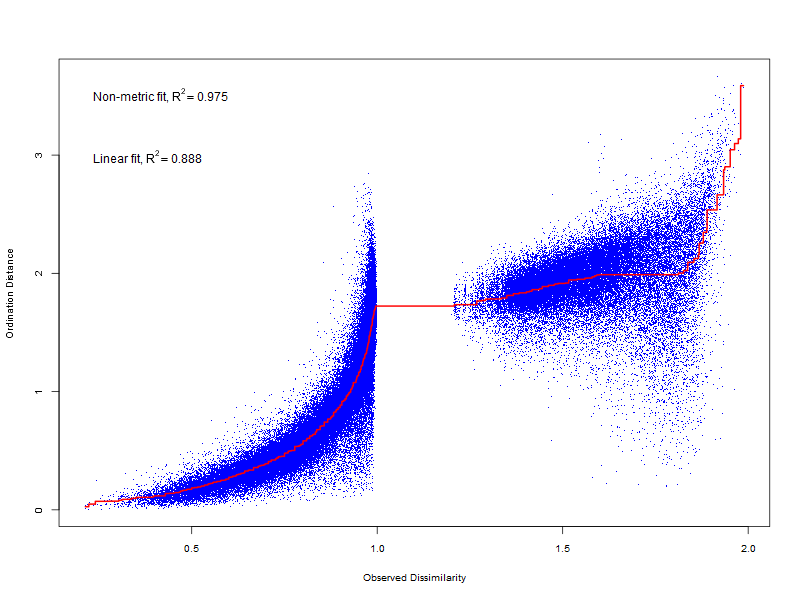

In [96]:
stressplot(nmds_scores, cex.lab=0.8, cex.axis=0.8, cex.main=0.8, cex.sub=0.8) # se explicar un R = 91 total con dos ejes

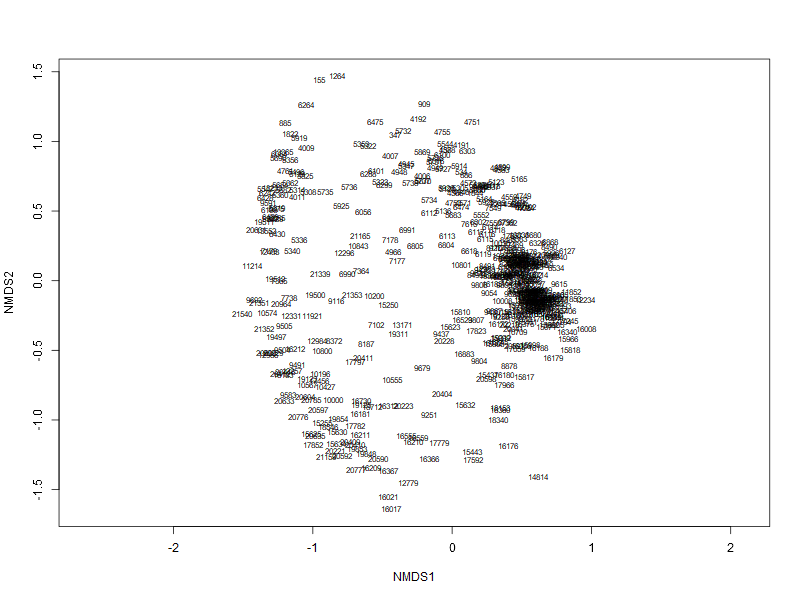

In [97]:
plot(nmds_scores)


## **5.3. Scores**

In [98]:
scores_nmds= scores(nmds_scores$points)

scores_nmds= as.data.frame(scores_nmds)
scores_nmds$id = as.numeric(rownames(scores_nmds))
head(scores_nmds)

           MDS1      MDS2        MDS3  id
155 -0.95508723 1.4396441  0.25202801 155
158 -0.04787829 0.9412605 -0.50988468 158
347 -0.41003916 1.0474572 -0.38373230 347
534  0.06243186 0.7772246 -0.35720916 534
885 -1.19714422 1.1332190  0.06088818 885
886  0.09832259 0.7619842 -0.27695309 886

In [99]:
dim(scores_nmds)

[1] 495   4

# **6. Export results**

In [100]:
grids_1km_buffer_filtered = grids_1km_buffer %>%
  filter(id %in% scores_nmds$id)%>%
  left_join(scores_nmds, by = "id")

In [101]:
st_write(grids_1km_buffer_filtered, "../../../DATOS/SHP/Biodiversidad/beta_div_nmds.shp", append=FALSE)

Deleting layer `beta_div_nmds' using driver `ESRI Shapefile'
Writing layer `beta_div_nmds' to data source 
  `../../../DATOS/SHP/Biodiversidad/beta_div_nmds.shp' using driver `ESRI Shapefile'
Writing 495 features with 8 fields and geometry type Polygon.
